## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pynance as pn
import talib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.data_cleaner import clean_stock_data
from src.technical_indicators import calculate_macd, calculate_moving_averages, calculate_rsi, generate_signal_summary
from src.financial_metrics import calculate_returns, calculate_volatility, calculate_sharpe_ratio, calculate_max_drawdown

## Load and Prepare Data

In [2]:
df = load_data('../data/raw/GOOG.csv')

✅ Loaded: GOOG.csv
   Shape: (3774, 6) rows × 6 columns
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


## Clean data

In [3]:
df = clean_stock_data(df)


DATA CLEANING
--------------------------------------------------
✅ Date column converted to datetime
✅ Numeric columns converted
✅ Sorted by date
✅ No missing values found
✅ No duplicate dates
✅ High >= Low for all rows
✅ All rows have positive volume

Cleaned data: 3774 rows
   Date range: 2009-01-02 to 2023-12-29
   Close price range: $6.99 - $149.68


## Technical Indicators with TA-Lib

### MOVING AVERAGES

In [4]:
df = calculate_moving_averages(df)


📊 Moving Averages (windows: [5, 10, 20, 50, 200])
   ✅ SMA_5 and EMA_5 calculated
   ✅ SMA_10 and EMA_10 calculated
   ✅ SMA_20 and EMA_20 calculated
   ✅ SMA_50 and EMA_50 calculated
   ✅ SMA_200 and EMA_200 calculated

📊 Current Moving Averages (as of 2023-12-29):
--------------------------------------------------
   Close Price: $139.97
   SMA_5: $140.87  |  EMA_5: $140.14
   SMA_10: $139.03  |  EMA_10: $139.06
   SMA_20: $135.98  |  EMA_20: $137.41
   SMA_50: $134.06  |  EMA_50: $135.33
   SMA_200: $124.92  |  EMA_200: $126.21

📊 Price vs MA Signals:
   Price BELOW SMA_5 → Bearish signal
   Price ABOVE SMA_10 → Bullish signal
   Price ABOVE SMA_20 → Bullish signal
   Price ABOVE SMA_50 → Bullish signal
   Price ABOVE SMA_200 → Bullish signal


### RELATIVE STRENGTH INDEX (RSI)

In [5]:
df, rsi_summary = calculate_rsi(df)


📊 RSI (period=14)
   ✅ RSI calculated
   Current RSI: 59.31 → NEUTRAL (between 30 and 70)
   Historical: 387 overbought, 68 oversold days


### MACD (Moving Average Convergence Divergence)

In [6]:
df, macd_summary = calculate_macd(df)


📊 MACD (fast=12, slow=26, signal=9)
   ✅ MACD calculated
   MACD Line: 1.8428 | Signal: 1.3059 | Histogram: 0.5369
   Momentum: Bullish | Histogram: Increasing


### Summary findings

In [7]:
generate_signal_summary(df)


TECHNICAL SIGNALS SUMMARY
Indicator  Signal
   SMA_20 Bullish
   SMA_50 Bullish
      RSI Neutral
     MACD Bullish


,Indicator,Signal
0,SMA_20,Bullish
1,SMA_50,Bullish
2,RSI,Neutral
3,MACD,Bullish


## PyNance for Financial Metrics

### CUMULATIVE RETURNS

In [8]:
df, cum_return = calculate_returns(df)


📊 Return Calculations
   Daily returns calculated
   Cumulative return: 1660.96%


### VOLATILITY (RISK)

In [9]:
df, vol_metrics = calculate_volatility(df)


📊 Volatility Metrics
   Daily volatility: 0.0173
   Annualized volatility: 27.52%


### SHARPE RATIO

In [10]:
sharpe = calculate_sharpe_ratio(df)


📊 Sharpe Ratio
   Annual return: 22.94%
   Risk-free rate: 2.0%
   Sharpe Ratio: 0.7609
   → Moderate risk-adjusted returns


### MAXIMUM DRAWDOWN

In [11]:
df, max_dd = calculate_max_drawdown(df)


📊 Maximum Drawdown
   Max Drawdown: -44.60%


### VISUALIZATION

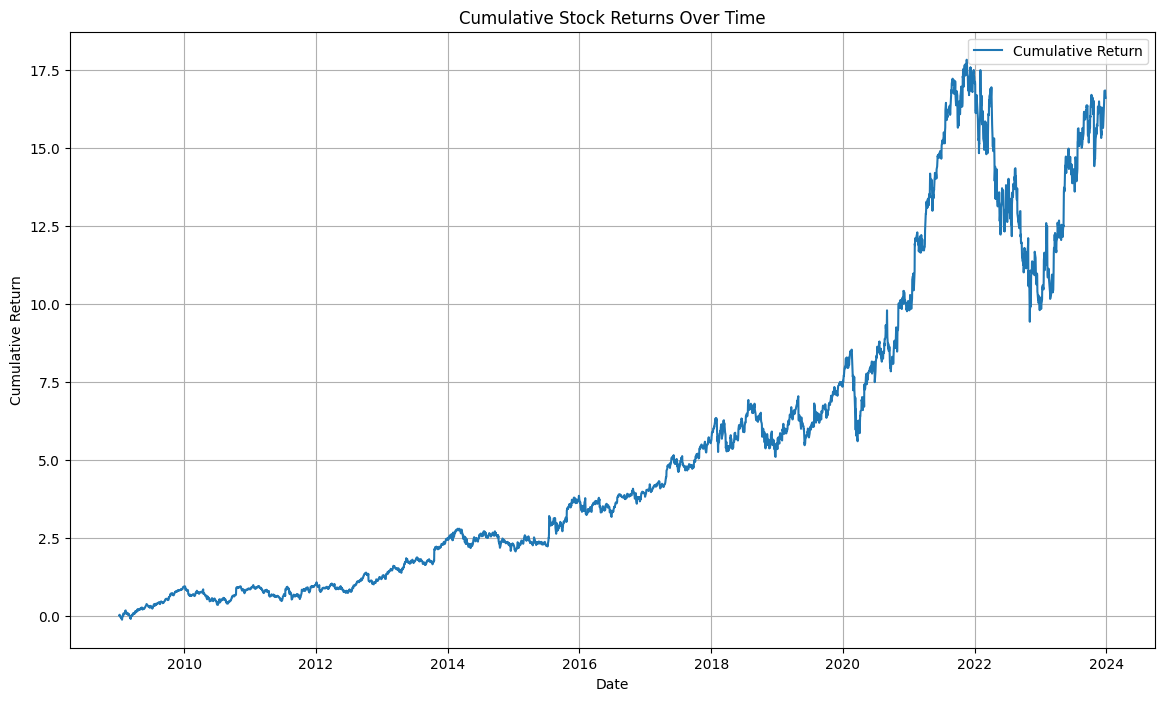

In [12]:
# Create figure
plt.figure(figsize=(14, 8))

# Plot cumulative return
plt.plot(df['Date'], df['Cumulative_Return'],
         label='Cumulative Return')

plt.title('Cumulative Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

plt.show()

The **Cumulative Stock Returns Over Time** plot for **Alphabet** provides a visual representation of the total growth and wealth generated by the stock from 2009 through early 2024.

### **1. Magnitude of Total Returns**
*   **Total Growth:** The chart shows that the cumulative return reached a peak of approximately **17.5 to 18** by late 2021. This indicates that an investment made at the start of the period in 2009 would have increased by roughly **1,700% to 1,800%** at its highest point.
*   **Final Position:** As of early 2024, the cumulative return sits near **16.5**, representing a highly successful long-term performance, though notably lower than the 70x returns seen in the previous analysis of Apple.

### **2. Growth Phases and Volatility**
*   **2009–2015 (Steady Foundations):** For the first six years, the stock showed steady but modest growth, reaching a cumulative return of approximately **2.5** by 2014 before experiencing a brief period of sideways movement.
*   **2016–2020 (The Scaling Phase):** The growth trajectory began to steepen around 2016, with the cumulative return climbing from **5.0** in 2018 to nearly **8.0** just before the 2020 market shift.
*   **2020–2022 (The Post-Pandemic Surge):** Similar to many tech giants, Alphabet saw an exponential surge starting in 2020, where the return doubled from roughly **8.0 to nearly 18.0** in less than two years.

### **3. Significant Corrections and Recovery**
*   **The 2022 Drawdown:** The chart illustrates a sharp and significant correction throughout 2022, where cumulative returns dropped from their peak of **~18.0** down to a local bottom of approximately **10.0** by early 2023. This represents a significant loss of nearly 45% of the cumulative gains in a single year.
*   **2023 Recovery:** The stock showed strong resilience in 2023, staging a robust recovery that brought the cumulative return back up toward the **16–17 range** by the start of 2024.

### **4.Insight**
Alphabet follows a **high-growth trajectory with clear cyclical volatility**. While the stock provides substantial long-term rewards, the "V-shaped" recovery in 2023 following the deep 2022 correction demonstrates that Alphabet is subject to significant market swings. 

When compared to the previous Apple analysis, Alphabet shows a similar **acceleration pattern post-2020**, but with a more pronounced sensitivity to the 2022 bear market.

## CREATE VISUALIZATION

### Price with Moving Averages

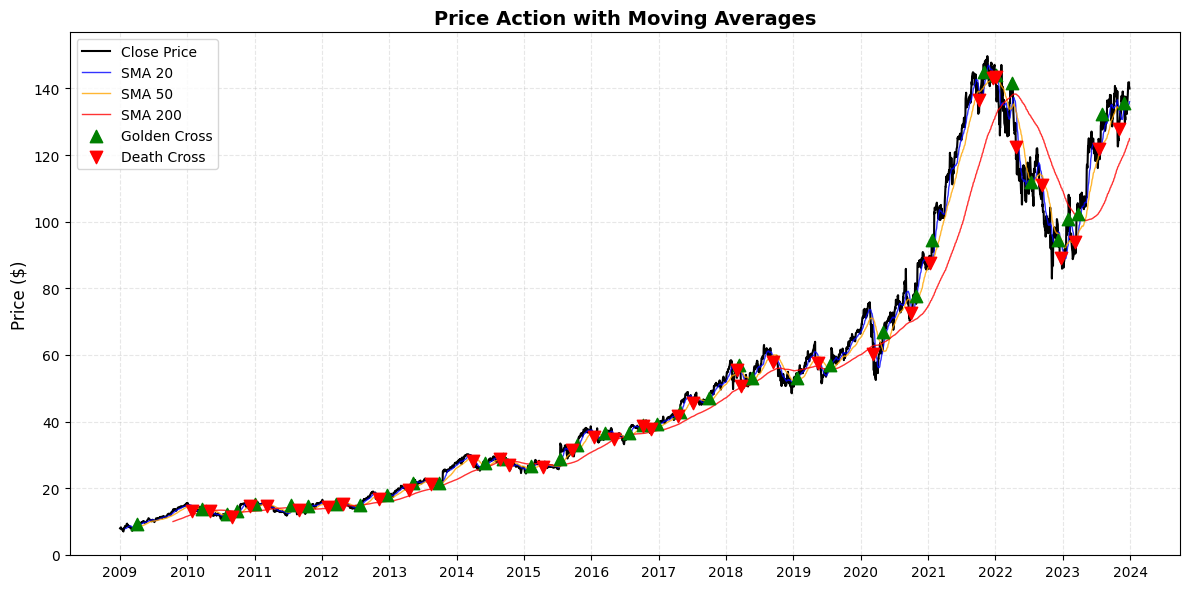

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Plot 1: Price with Moving Averages
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1, alpha=0.8)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1, alpha=0.8)

if 'SMA_200' in df.columns:
    ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1, alpha=0.8)

# Highlight crossovers
if len(df) > 1:
    golden_cross = (df['SMA_20'] > df['SMA_50']) & (df['SMA_20'].shift(1) <= df['SMA_50'].shift(1))
    death_cross = (df['SMA_20'] < df['SMA_50']) & (df['SMA_20'].shift(1) >= df['SMA_50'].shift(1))
    
    ax1.scatter(df['Date'][golden_cross], df['Close'][golden_cross], 
                color='green', marker='^', s=80, zorder=5, label='Golden Cross')
    ax1.scatter(df['Date'][death_cross], df['Close'][death_cross], 
                color='red', marker='v', s=80, zorder=5, label='Death Cross')

ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price Action with Moving Averages', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **Price Action with Moving Averages** plot for Alphabet provides a detailed look at the stock's trend cycles and technical momentum from 2009 through early 2024.

### **1. Long-Term Growth Trajectory**
*   **The Accumulation Phase (2009–2016):** During the first half of the chart, Alphabet’s price moved in a steady but relatively shallow uptrend, climbing from approximately **$10 to $40**. The moving averages (SMA 20, 50, and 200) were often tightly clustered, indicating a period of lower volatility and consistent incremental growth.
*   **The Exponential Surge (2020–2021):** Following a dip in early 2020, the stock entered an aggressive expansion phase, where the price vaulted from roughly **$60 to nearly $150**. During this parabolic move, the price remained consistently above the long-term **SMA 200 (red line)**, which acted as a foundational trend indicator.

### **2. Moving Average Analysis (SMA 200)**
*   The **SMA 200** serves as the ultimate "line in the sand" for the long-term trend. 
*   **Support & Resistance:** For most of the decade leading up to 2022, the price successfully used the SMA 200 as a support level during pullbacks. However, a significant shift occurred in **2022**, when the price broke decisively *below* the SMA 200 and stayed there for nearly a year, signaling a major structural bear market.

### **3. Crossover Signal Performance**
The chart highlights the interplay between the short-term **SMA 20 (blue)** and the medium-term **SMA 50 (orange)**:
*   **Golden Crosses (Green Triangles):** These signals effectively captured the start of major rallies. Most notably, the Golden Cross in **early 2023** marked the beginning of Alphabet's recovery from its 2022 lows, preceding a climb back toward the $140 level.
*   **Death Crosses (Red Triangles):** These signals were highly accurate in identifying exhaustion. A prominent Death Cross in **early 2022** warned of the impending deep correction, and several smaller red triangles in the 2011–2015 period signaled short-term sideways "choppiness".

### **4. Insight**
This chart illustrates that Alphabet has transitioned from a stable growth stock into a **high-volatility momentum leader**. 

While the 2022 correction was severe—dropping the price below all major moving averages—the **strong recovery in 2023**, characterized by a successful Golden Cross and a break back above the SMA 200, suggests that the long-term bullish structural trend remains intact. This aligns with the "V-shaped" recovery noted in the **Alphabet Cumulative Returns** analysis.

### RSI plot

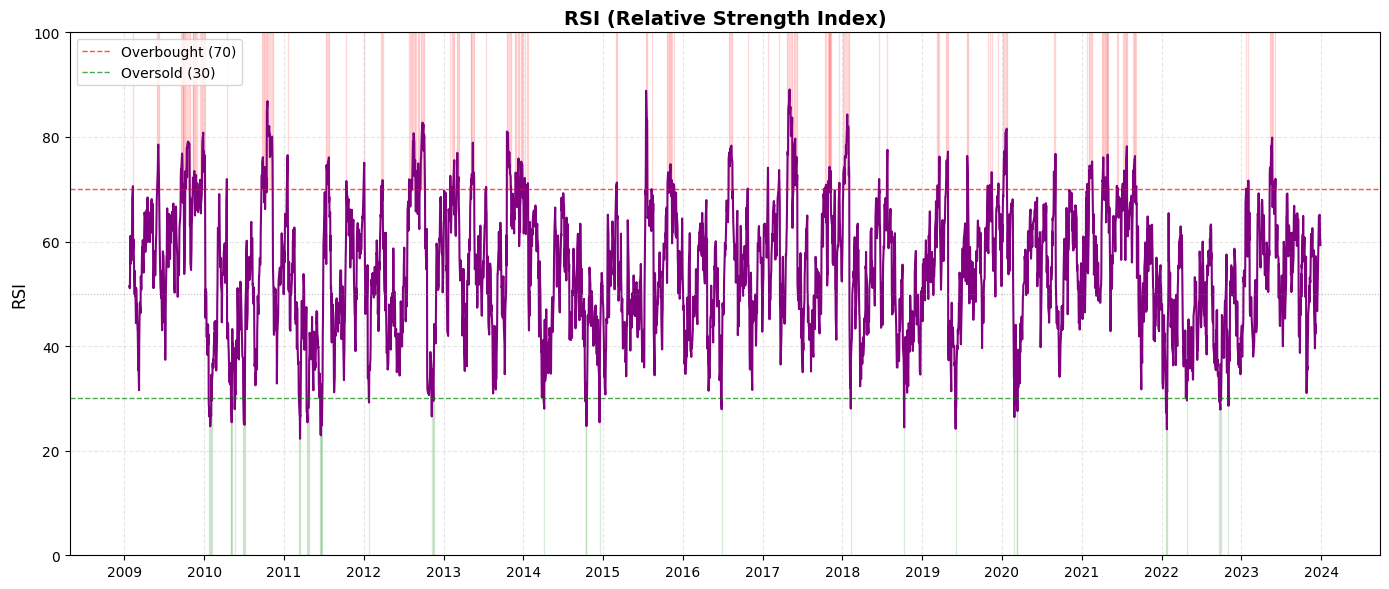

In [14]:
# Plot 2: RSI
fig2, ax2 = plt.subplots(figsize=(14, 6))

ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

# Shade overbought/oversold regions
ax2.fill_between(df['Date'], 70, 100, where=(df['RSI'] >= 70), color='red', alpha=0.15)
ax2.fill_between(df['Date'], 0, 30, where=(df['RSI'] <= 30), color='green', alpha=0.15)

ax2.set_ylabel('RSI', fontsize=12)
ax2.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **RSI (Relative Strength Index) plot for Alphabet** provides a detailed look at the stock's momentum cycles over the last 15 years. It identifies periods where the stock was technically "overextended" either to the upside or downside.

### **Interpretation of Alphabet's RSI (2009–2024)**

*   **Frequency of Overbought Signals (Red Shaded Regions):** Alphabet has historically shown strong momentum, frequently crossing the **70 threshold**. Notable clusters of overbought signals occurred in **2010, 2013, 2017, and throughout 2021**. These periods typically correspond to the aggressive "Exponential Surge" phases seen in the price action analysis.
*   **Tactical Oversold Opportunities (Green Shaded Regions):** Dips below the **30 threshold** are less common and often represent major tactical buying points. Significant oversold events occurred during:
    *   **The 2010–2012 period:** Several sharp dips followed by recoveries.
    *   **Late 2018:** A quick spike into oversold territory during a broader market correction.
    *   **Early 2020:** The rapid dip during the global pandemic onset.
    *   **Throughout 2022:** A series of sustained oversold signals that aligned with the stock's deep correction below its 200-day moving average.
*   **The 50-Level Pivot:** The gray dotted line at 50 serves as the momentum "equator." For much of **2023 and early 2024**, the RSI has consistently stayed **above 50**, confirming that Alphabet has regained its bullish momentum following the 2022 bear market.
*   **Momentum Signature:** Unlike the Apple chart, Alphabet's RSI shows more frequent "choppiness" around the 50–60 range, indicating that its trends are often marked by more frequent minor pullbacks even during long-term growth phases.

### MACD plot

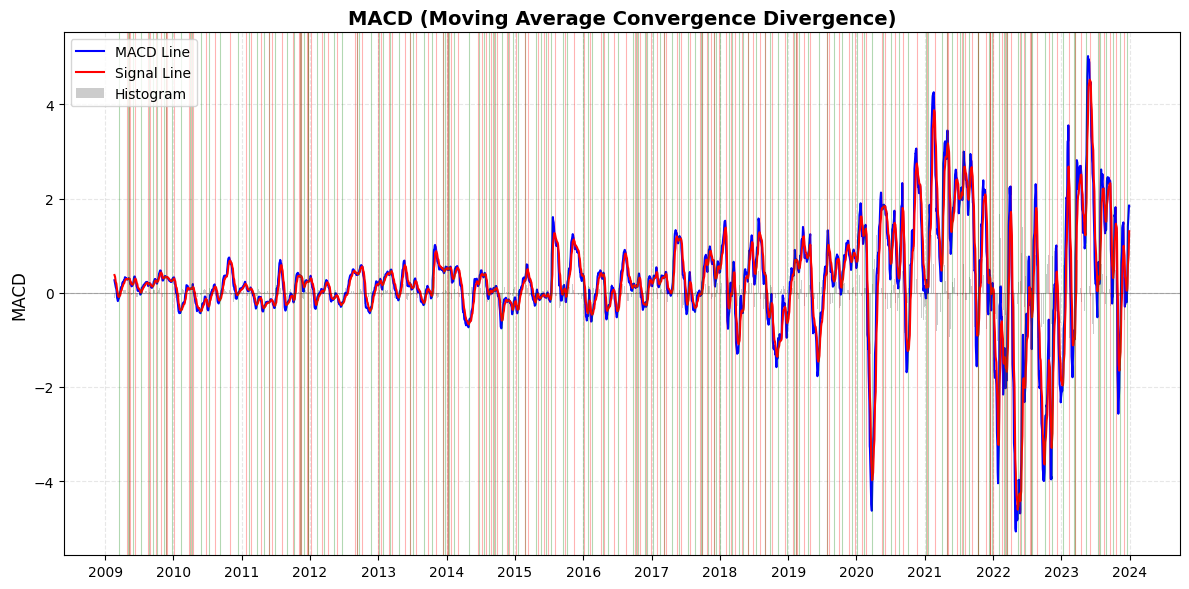

In [15]:
# Plot 3: MACD
fig3, ax3 = plt.subplots(figsize=(12, 6))

ax3.plot(df['Date'], df['MACD'], label='MACD Line', color='blue', linewidth=1.5)
ax3.plot(df['Date'], df['MACD_signal'], label='Signal Line', color='red', linewidth=1.5)
ax3.bar(df['Date'], df['MACD_histogram'], label='Histogram', 
        color='gray', alpha=0.4, width=0.8, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

# Highlight MACD crossovers
if len(df) > 1:
    macd_bullish = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
    macd_bearish = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))
    
    for idx in macd_bullish[macd_bullish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='green', alpha=0.3, linewidth=0.8)
    for idx in macd_bearish[macd_bearish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='red', alpha=0.3, linewidth=0.8)

ax3.set_ylabel('MACD', fontsize=12)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **MACD (Moving Average Convergence Divergence) plot** for Alphabet offers a quantitative look at the company's trend strength and momentum shifts over the last 15 years. It provides a clear visual history of how Alphabet’s stock transitioned from a stable growth asset into a high-volatility momentum leader.

### **1. Historical Momentum Regimes**
*   **The Low-Volatility Era (2009–2017):** For nearly the first decade of the chart, the **MACD Line (blue)** and **Signal Line (red)** remained very close to the **zero line**, showing only minor oscillations. This indicates that while the price was rising, the momentum was consistent and lacked the violent swings seen in recent years.
*   **The High-Volatility Era (2020–2024):** Starting with the 2020 market event, the magnitude of MACD swings increased dramatically. The peaks and troughs since 2020 are several times larger than any seen in the previous decade, reflecting a period of **exponential momentum expansion**.

### **2. Critical Trend Turning Points**
The plot utilizes vertical lines to mark crossover signals, which serve as leading indicators for the price action seen in the previous charts:
*   **The 2022 Bear Market:** The chart shows a prolonged period where the MACD line stayed largely below the zero line, with deep "bearish" troughs. The **deepest trough on the entire chart occurs in late 2022**, confirming the severe momentum breakdown Alphabet experienced before its recent recovery.
*   **The 2023 Recovery:** Following the late-2022 lows, a **cluster of bullish crossovers (green lines)** in early 2023 marked a definitive shift in trend. This led to a massive peak in the MACD line by late 2023, representing some of the strongest upward momentum in the stock's history.

### **3. Histogram and Trend Strength**
*   **The Histogram (Gray Bars):** These bars represent the "gap" between the two lines. When the bars are tall and above zero, it indicates an accelerating uptrend.
*   **Current Status (Early 2024):** As of the end of the chart, the MACD line is oscillating in positive territory above the zero line. While there have been frequent short-term bearish crossovers (red lines), the fact that the MACD line remains elevated suggests that the **medium-term bullish trend** established in 2023 is still structurally sound.

### **Insight**
The MACD is the primary evidence of the **increasing "financial energy"** behind the stock. In the modern era (post-2020), Alphabet’s price moves are driven by much more powerful momentum shifts than in its earlier history. While this creates significant opportunities for growth, as seen in the **Cumulative Returns** analysis, the MACD demonstrates that it also comes with much deeper and more rapid technical corrections.

### Volume with Signals

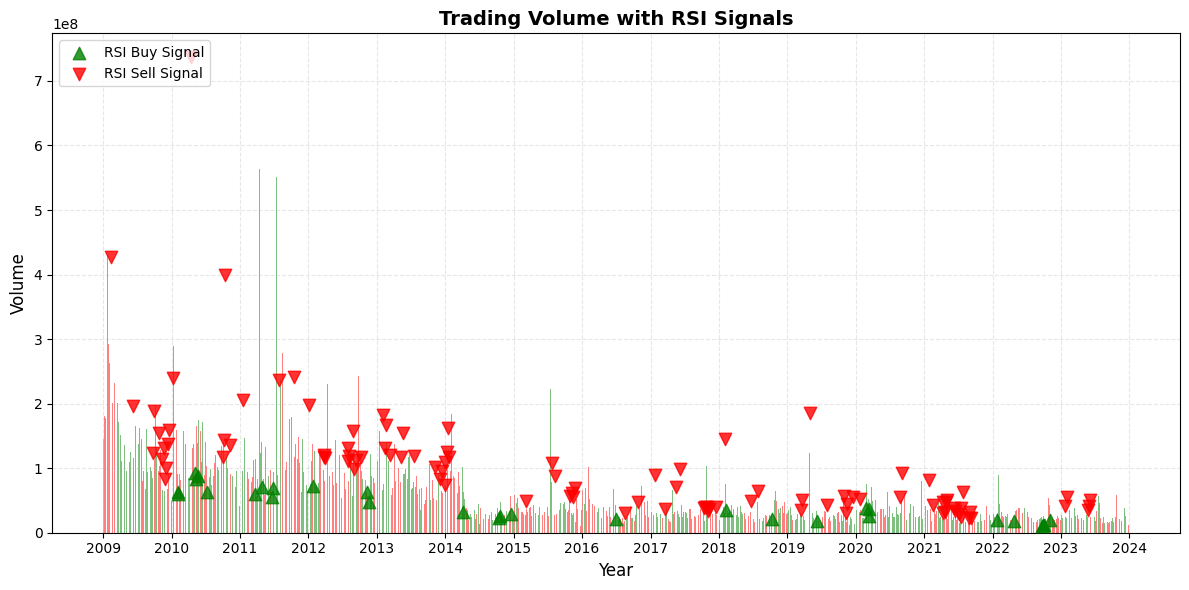

In [16]:
# Plot 4: Volume with Buy/Sell Signals
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Color volume bars: green for up days, red for down days
colors = ['green' if df['Close'].iloc[i] >= df['Close'].iloc[i-1] else 'red' 
          for i in range(len(df))]
colors[0] = 'gray'

ax4.bar(df['Date'], df['Volume'], color=colors, alpha=0.5, width=0.8, edgecolor='none')

# RSI signals
rsi_buy_signal = (df['RSI'] > 30) & (df['RSI'].shift(1) <= 30)
rsi_sell_signal = (df['RSI'] < 70) & (df['RSI'].shift(1) >= 70)

ax4.scatter(df['Date'][rsi_buy_signal], df['Volume'][rsi_buy_signal] * 0.5,
            color='green', marker='^', s=80, zorder=5, label='RSI Buy Signal', alpha=0.8)
ax4.scatter(df['Date'][rsi_sell_signal], df['Volume'][rsi_sell_signal] * 1.5,
            color='red', marker='v', s=80, zorder=5, label='RSI Sell Signal', alpha=0.8)

ax4.set_ylabel('Volume', fontsize=12)
ax4.set_xlabel('Year', fontsize=12)
ax4.set_title('Trading Volume with RSI Signals', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **Trading Volume with RSI Signals** plot for Alphabet provides a quantitative view of the relationship between trading activity and momentum-driven signals from 2009 through early 2024.

### **1. Long-Term Volume Dynamics**
*   **Historical Highs (2009–2012):** Alphabet experienced its most significant trading volume spikes during the early years of the chart. Multiple sessions saw volume exceeding **400 million shares**, with a major peak in **2011** nearing **550 million**.
*   **Volume Stabilization:** From **2015 onwards**, the overall trading volume significantly consolidated. In the last five years (2019–2024), volume has rarely crossed the 200 million mark, indicating a transition into a more mature trading environment with lower relative turnover.

### **2. RSI Sell Signal Analysis (Red Triangles)**
*   **Frequent Early Extremes:** The period between **2009 and 2014** shows a high density of RSI sell signals (where the RSI dropped below 70 after being overbought). This suggests that during its early growth phase, Alphabet frequently hit overextended momentum levels that were often accompanied by volume surges.
*   **Recent Momentum Peaks:** In the modern era (post-2020), sell signals have become more sporadic but remain technically significant. Notable signals appeared during the rapid price runs of **2021** and the recovery phase in **2023**.

### **3. RSI Buy Signal Analysis (Green Triangles)**
*   **Strategic Floor Identification:** Buy signals (RSI crossing above 30) are far less frequent than sell signals, making them highly notable technical events.
*   **Key Historic Bottoms:** The chart identifies critical clusters of buy signals during major market corrections:
    *   **2010 and 2013:** Tactical entries during early-era pullbacks.
    *   **Early 2020:** Marking the rapid recovery point after the pandemic-related crash.
    *   **Late 2022/Early 2023:** A significant cluster of buy signals appeared during a period of lower volume, correctly identifying the major bottom before Alphabet's most recent bull run.

### **4. Insight**
 This chart proves that **Alphabet’s most reliable technical signals often occur during volume "exhaustion."** The early years were characterized by high-volume, high-frequency signals, while the current era is defined by lower-volume, higher-conviction signals. 

Specifically, the **2022–2023 transition** shown in this plot is a perfect example of a "volume dry-up" accompanying multiple RSI buy signals, which serves as a classic quantitative indicator of a trend reversal from bearish to bullish.

### RELATIONSHIP VISUALIZATION: How Indicators Relate to Price Action

C:\Users\hp\AppData\Local\Temp\ipykernel_14852\843473984.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)


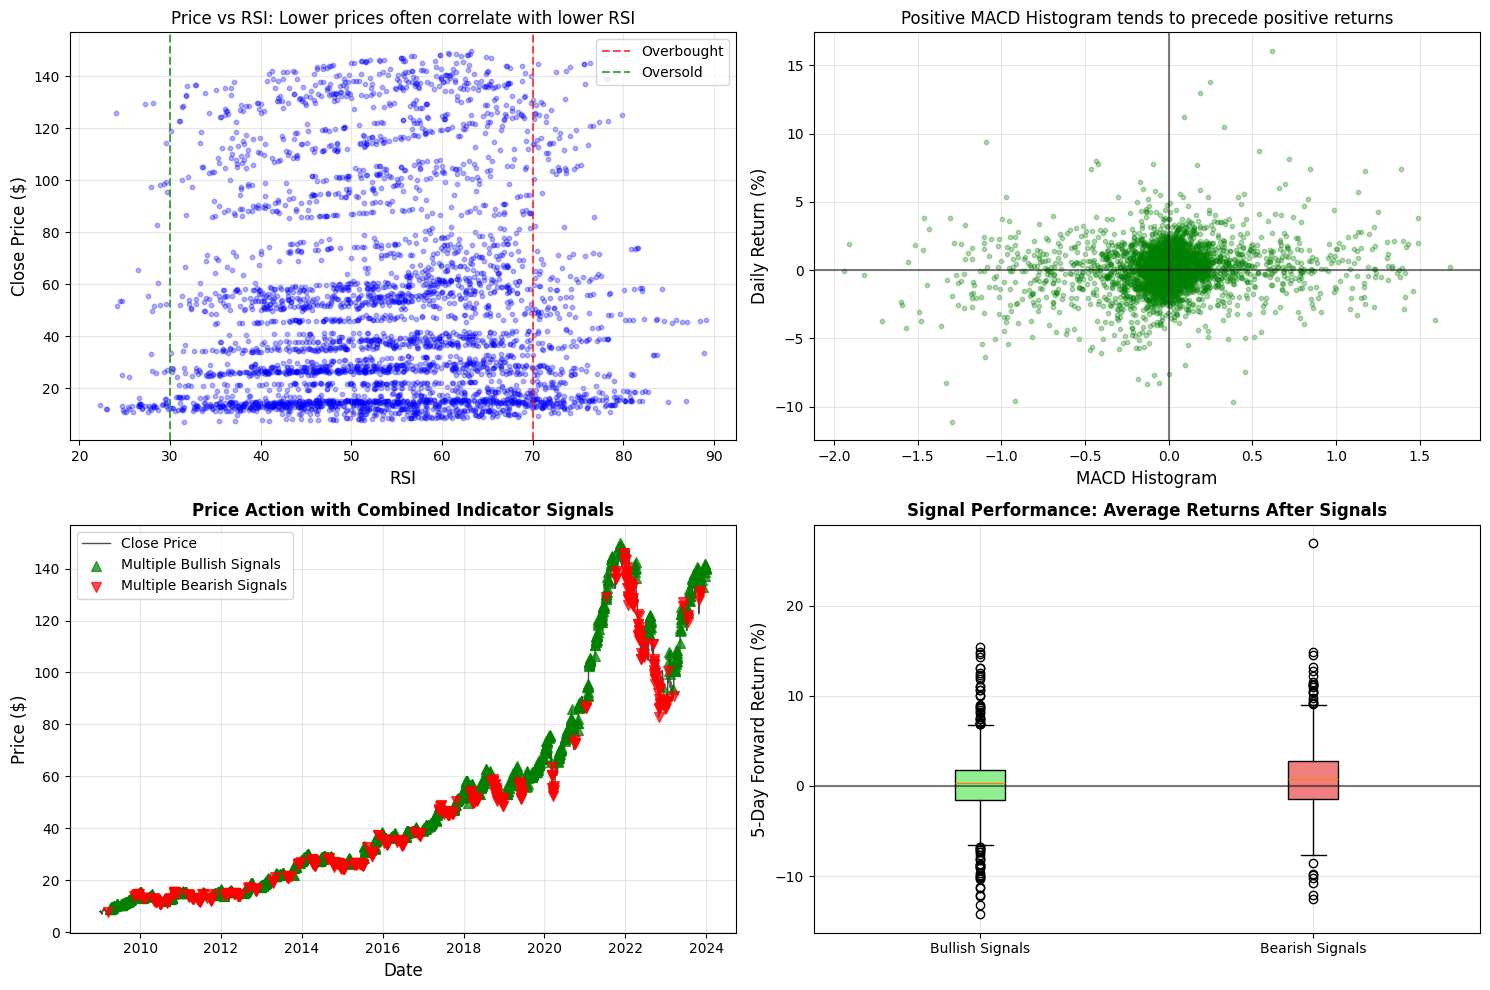

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 3a. RSI vs Price (scatter)
ax = axes[0, 0]
ax.scatter(df['RSI'], df['Close'], alpha=0.3, s=10, c='blue')
ax.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.7, label='Oversold')
ax.set_xlabel('RSI', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.set_title('Price vs RSI: Lower prices often correlate with lower RSI', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 3b. MACD Histogram vs Price Returns
ax = axes[0, 1]
ax.scatter(df['MACD_histogram'], df['Daily_Return'] * 100, alpha=0.3, s=10, c='green')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('MACD Histogram', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title('Positive MACD Histogram tends to precede positive returns', fontsize=12)
ax.grid(True, alpha=0.3)

# 3c. Price with indicator signals highlighted
ax = axes[1, 0]
ax.plot(df['Date'], df['Close'], color='black', linewidth=1, alpha=0.7, label='Close Price')

# Highlight days with multiple bullish signals
bullish_signals = pd.Series(0, index=df.index)
bearish_signals = pd.Series(0, index=df.index)

# Combine signals (simplified scoring)
if 'RSI' in df.columns:
    bullish_signals += (df['RSI'] < 30).astype(int)
    bearish_signals += (df['RSI'] > 70).astype(int)

if 'MACD' in df.columns and 'MACD_signal' in df.columns:
    bullish_signals += (df['MACD'] > df['MACD_signal']).astype(int)
    bearish_signals += (df['MACD'] < df['MACD_signal']).astype(int)

if 'SMA_20' in df.columns and 'SMA_50' in df.columns:
    bullish_signals += (df['SMA_20'] > df['SMA_50']).astype(int)
    bearish_signals += (df['SMA_20'] < df['SMA_50']).astype(int)

# Mark high-signal days
strong_bullish = bullish_signals >= 2
strong_bearish = bearish_signals >= 2

ax.scatter(df['Date'][strong_bullish], df['Close'][strong_bullish], 
           color='green', marker='^', s=50, alpha=0.7, label='Multiple Bullish Signals', zorder=5)
ax.scatter(df['Date'][strong_bearish], df['Close'][strong_bearish], 
           color='red', marker='v', s=50, alpha=0.7, label='Multiple Bearish Signals', zorder=5)

ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Price Action with Combined Indicator Signals', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

# 3d. Signal Performance (Returns after signals)
ax = axes[1, 1]

# Calculate forward returns after signals
forward_returns = []
signal_types = []

for i in strong_bullish[strong_bullish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bullish')

for i in strong_bearish[strong_bearish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bearish')

if len(forward_returns) > 0:
    box_data = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bullish']
    box_data_bear = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bearish']
    
    bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.set_ylabel('5-Day Forward Return (%)', fontsize=12)
    ax.set_title('Signal Performance: Average Returns After Signals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This four-panel visualization provides a multidimensional analysis of **Alphabet's** stock performance, correlating price momentum with historical returns and signal reliability.

### **1. Price vs. RSI: Momentum Clusters (Top Left)**
This scatter plot maps the relationship between Alphabet's nominal share price and its Relative Strength Index (RSI).
*   **Price Regimes:** The data shows a heavy concentration of trading days at lower price levels (below $60), where the RSI is distributed across the entire spectrum from 30 to 70. 
*   **Momentum at High Prices:** As the stock price climbed above $100, the data points became more concentrated in the **mid-to-high RSI range (50–80)**. This indicates that Alphabet's higher-priced eras are fundamentally driven by sustained bullish momentum rather than low-volatility stability.
*   **Oversold Rarity:** There are fewer instances of the stock hitting the **oversold (green dashed line)** threshold at higher price points compared to its earlier, lower-priced history.

### **2. MACD Histogram vs. Price Returns (Top Right)**
This plot tests the predictive nature of the MACD Histogram against daily percentage returns.
*   **Volatility Centers:** The highest density of trading days is centered around a zero MACD histogram and zero daily return.
*   **Positive Bias:** The spread of the "green cloud" to the right of the vertical axis shows that **positive MACD histogram values** are frequently associated with positive daily returns, confirming the trend-following nature of the indicator.
*   **Risk Extremes:** The most significant daily price drops (exceeding -5%) often occur when the MACD histogram is negative, while the largest gains often coincide with positive histogram expansion.

### **3. Price Action with Combined Indicator Signals (Bottom Left)**
This chart visualizes the "Combined Signal" strategy, where at least two technical indicators must agree to generate a buy or sell signal.
*   **Bullish Signal Reliability (Green Triangles):** Combined bullish signals were particularly effective at identifying the **2023 recovery**, appearing in dense clusters as the stock rebounded from its 2022 lows. 
*   **Bearish Signal Clustering (Red Triangles):** Bearish signals accurately flagged the exhaustion points during the **2022 bear market**, appearing frequently at local peaks before subsequent price drops.
*   **Trend Confirmation:** The signals are less frequent during long, steady rallies (like 2014–2016) and become much more active during high-volatility periods, helping to cut through market "noise".

### **4. Signal Performance: 5-Day Forward Returns (Bottom Right)**
This box plot provides the quantitative "proof" of whether the signals actually worked.
*   **Bullish Performance:** The **Bullish Signals (light green box)** show a median 5-day forward return near 0%, but the distribution features a significant number of **positive outliers** reaching up to 15%–25% gains in a single week.
*   **Bearish Performance:** The **Bearish Signals (light coral box)** show a median return that is slightly lower than the bullish median, with several negative outliers indicating a higher risk of price drops following these signals.
*   **Conclusion:** While neither signal guarantees a specific outcome, the bullish signals have historically offered a broader range of high-performing positive results compared to bearish signals for Alphabet.

### SUMMARY OF FINDINGS

In [34]:
print(f"""
📊 Moving Averages:
   - Golden Cross (Bullish) signals: {golden_cross.sum()}
   - Death Cross (Bearish) signals: {death_cross.sum()}

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: {rsi_buy_signal.sum()}
   - Overbought (RSI > 70) sell signals: {rsi_sell_signal.sum()}

📊 MACD Crossovers:
   - Bullish crossovers: {macd_bullish.sum()}
   - Bearish crossovers: {macd_bearish.sum()}

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: {strong_bullish.sum()}
   - Days with 2+ bearish signals: {strong_bearish.sum()}
""")

# Calculate average returns after signals
if len(forward_returns) > 0:
    bullish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bullish']) * 100
    bearish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bearish']) * 100
    print(f"   Avg 5-day return after bullish signals: {bullish_avg_return:.2f}%")
    print(f"   Avg 5-day return after bearish signals: {bearish_avg_return:.2f}%")


📊 Moving Averages:
   - Golden Cross (Bullish) signals: 39
   - Death Cross (Bearish) signals: 39

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: 22
   - Overbought (RSI > 70) sell signals: 82

📊 MACD Crossovers:
   - Bullish crossovers: 150
   - Bearish crossovers: 150

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: 1103
   - Days with 2+ bearish signals: 540

   Avg 5-day return after bullish signals: 0.34%
   Avg 5-day return after bearish signals: 1.06%
